# Atividade 02 b - PDI

| Informações |  Detalhes                                      |
| :--- |:-----------------------------------------------|
| **Disciplina:** | Introdução ao Processamento Digital de Imagens |
| **Tema:** | Atividade 02b                                  |
| **Professor:** | Prof. Dr. Wagner Ferreira de Barros            |
| **Data:** | 02 de maio de 2026                             |
| **Integrantes:** | João Vitor Ribeiro Botelho                     |

---

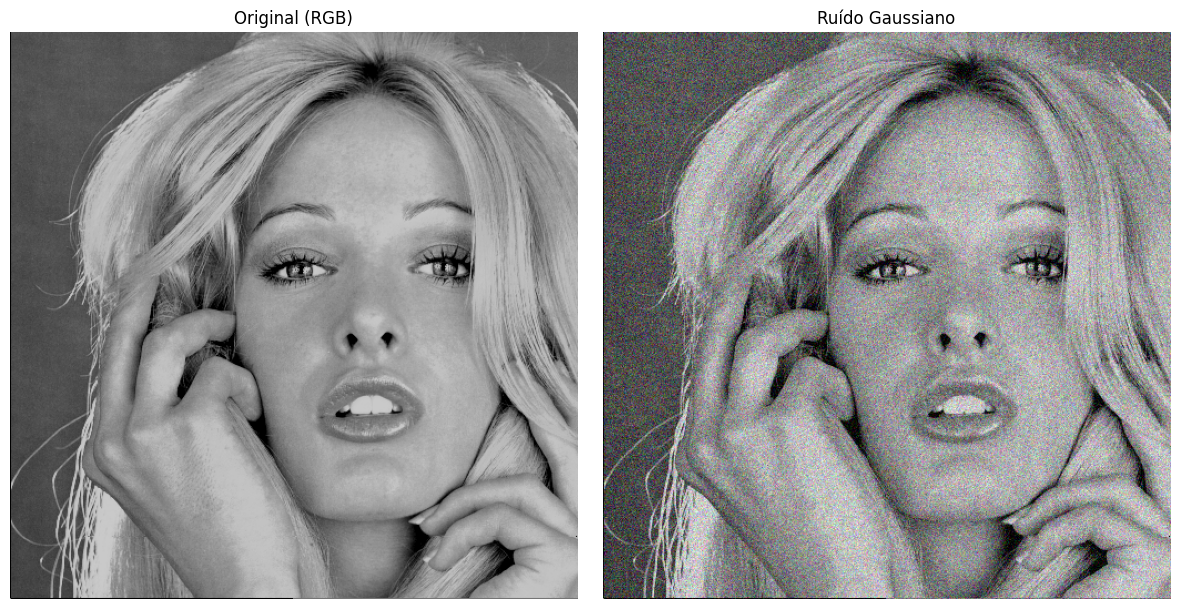

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path
from skimage.util import random_noise

base_path = Path("Dataset")
img_file = base_path / "woman_blonde.tif"

imgpath = str(img_file.absolute())
img = cv2.imread(imgpath, 1)

if img is None:
    print(f"ERRO CRÍTICO: Imagem não encontrada em: {imgpath}")
    print(f"Diretório atual de execução: {os.getcwd()}")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_noisy = random_noise(img, mode='gaussian', clip=True)

    plt.figure(figsize=(12, 6))

    plt.subplot(121)
    plt.imshow(img)
    plt.title('Original (RGB)')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(img_noisy)
    plt.title('Ruído Gaussiano')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    img1 = np.uint8(img_noisy * 255)

# Exercícios

## Exercício 1 - Suavização por Média

Aplique o filtro da média em uma imagem do dataset disponibilizado
utilizando diferentes tamanhos de kernel (3 × 3, 5 × 5, 7 × 7). Observe e descreva o efeito do
aumento do kernel na nitidez e na suavização da imagem.

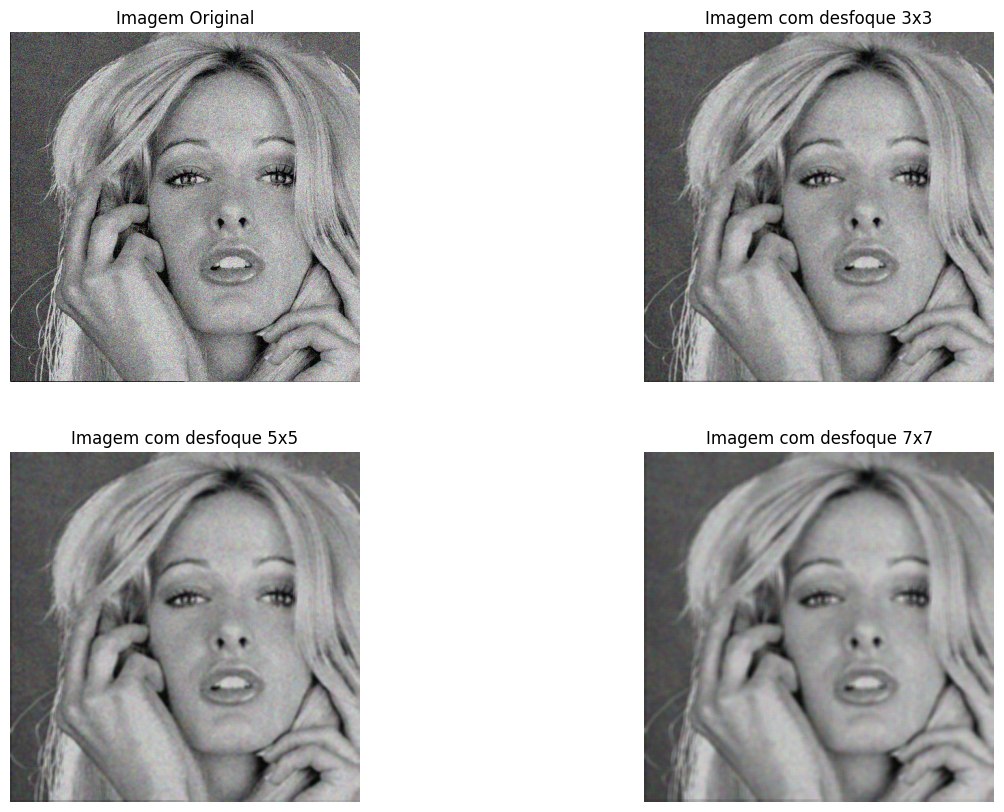

In [35]:
img1_filtered3x3 = cv2.blur(img1, [3, 3])
img1_filtered5x5 = cv2.blur(img1, [5, 5])
img1_filtered7x7 = cv2.blur(img1, [7, 7])

plt.figure( figsize=(15, 10))
plt.subplot(2, 2, 1), plt.axis('off'), plt.imshow(img1), plt.title('Imagem Original')
plt.subplot(2, 2, 2), plt.axis('off'), plt.imshow(img1_filtered3x3), plt.title('Imagem com desfoque 3x3')
plt.subplot(2, 2, 3), plt.axis('off'), plt.imshow(img1_filtered5x5), plt.title('Imagem com desfoque 5x5')
plt.subplot(2, 2, 4), plt.axis('off'), plt.imshow(img1_filtered7x7), plt.title('Imagem com desfoque 7x7')


plt.show()

### Metodologia
A metodologia adotada consistiu na aplicação de técnicas de processamento espacial linear para a suavização de sinais de imagem, utilizando o Filtro de Média. O procedimento foi estruturado através da operação de convolução, onde máscaras quadradas de coeficientes unitários (kernels) com dimensões ímpares de $3 \times 3$, $5 \times 5$ e $7 \times 7$ foram deslizadas sobre a imagem ruidosa. Em cada posição, calculou-se a média aritmética das intensidades dos pixels contidos na vizinhança definida pelo kernel, substituindo o valor do pixel central por esse resultado. Para a análise comparativa, utilizou-se uma grade de visualização $2 \times 2$ via Matplotlib, permitindo a observação qualitativa da degradação da nitidez e da atenuação do ruído conforme o aumento do domínio espacial da máscara, evidenciando o comportamento do filtro como um operador de baixa frequência.

### Análise
Ao aplicar o filtro de média com o kernel 3x3, já é possível notar uma redução nos ruídos da imagem. Porém, detalhes de textura ainda são preservados. Conforme aumentamos o tamanho do kernel, estes detalhes vão sendo "borrados" pelo processamento, gerando regiões de cor mais homogêneas.
Quanto maior a capacidade de suavização e remoção de ruído, menor será a nitidez e a preservação dos detalhes estruturais da imagem.



## Exercício 2 - Ruído Sal e Pimenta
Gere uma imagem com ruído do tipo sal e pimenta. Aplique o filtro
da mediana com diferentes tamanhos de kernel. Compare os resultados de forma subjetiva
(análise visual) e objetiva (desenvolva ou utilize uma métrica de erro, como MSE ou PSNR,
para comparar com a imagem original).


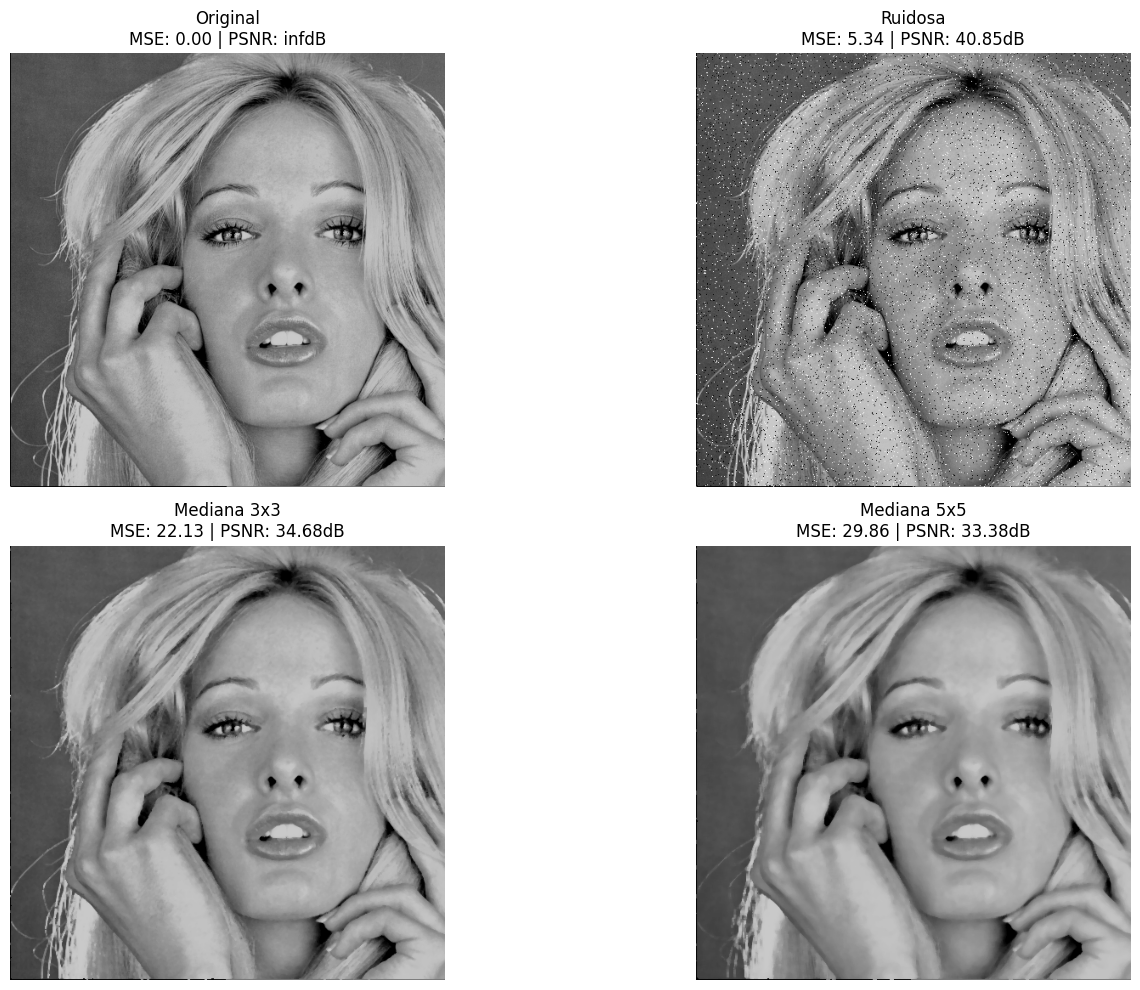

Original -> MSE:     0.00 | PSNR:   inf dB
Ruidosa -> MSE:     5.34 | PSNR: 40.85 dB
Mediana 3x3 -> MSE:    22.13 | PSNR: 34.68 dB
Mediana 5x5 -> MSE:    29.86 | PSNR: 33.38 dB
Mediana 7x7 -> MSE:    34.15 | PSNR: 32.80 dB


In [36]:
# Funções para Métricas Objetivas
def calculate_mse(img_orig, img_proc):
    # Mean Squared Error: Quanto menor, mais parecida com a original
    return np.mean((img_orig - img_proc) ** 2)

def calculate_psnr(img_orig, img_proc):
    # Peak Signal-to-Noise Ratio: Quanto maior, melhor a qualidade
    mse = calculate_mse(img_orig, img_proc)
    if mse == 0: return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

#  Gerar Ruído Sal e Pimenta
noisy = img.copy()
p = 0.05 # Probabilidade do ruído
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        r = random.random()
        if r < p/2:
            noisy[i, j] = [0, 0, 0]      # Pimenta
        elif r < p:
            noisy[i, j] = [255, 255, 255] # Sal

# Aplicar Filtro de Mediana com diferentes Kernels
denoised_3 = cv2.medianBlur(noisy, 3)
denoised_5 = cv2.medianBlur(noisy, 5)
denoised_7 = cv2.medianBlur(noisy, 7)

# Cálculos das Métricas
metrics = {
    "Original": (0, calculate_psnr(img, img)), # Referência
    "Ruidosa": (calculate_mse(img, noisy), calculate_psnr(img, noisy)),
    "Mediana 3x3": (calculate_mse(img, denoised_3), calculate_psnr(img, denoised_3)),
    "Mediana 5x5": (calculate_mse(img, denoised_5), calculate_psnr(img, denoised_5)),
    "Mediana 7x7": (calculate_mse(img, denoised_7), calculate_psnr(img, denoised_7))
}

plt.figure(figsize=(16, 10))

titles = ['Original', 'Ruidosa', 'Mediana 3x3', 'Mediana 5x5']
images = [img, noisy, denoised_3, denoised_5]

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    label = titles[i]
    plt.title(f"{label}\nMSE: {metrics[label][0]:.2f} | PSNR: {metrics[label][1]:.2f}dB")
    plt.axis('off')

plt.tight_layout()
plt.show()

for k, v in metrics.items():
    print(f"{k} -> MSE: {v[0]:>8.2f} | PSNR: {v[1]:>5.2f} dB")

### Metodologia
A metodologia aplicada consistiu no processamento digital de uma imagem ruidosa utilizando técnicas de filtragem espacial no domínio da intensidade. Inicialmente, foi gerado um ruído do tipo "Sal e Pimenta" (ruído de impulso), onde pixels aleatórios tiveram seus valores substituídos por intensidades extremas (0 para preto e 255 para branco). Para a restauração da imagem, utilizou-se o Filtro de Mediana, um operador não-linear que percorre a imagem com uma janela (kernel) de dimensões ímpares ($3 \times 3$, $5 \times 5$, etc.). Diferente do filtro de média, a técnica de mediana ordena os valores dos pixels na vizinhança e seleciona o valor central da lista para substituir o pixel de referência. Por fim, foram calculadas métricas de erro quadrático médio (MSE) e relação sinal-ruído de pico (PSNR) para quantificar a eficiência da filtragem em relação à imagem original.

### Análise e Resultados
A análise visual demonstrou que o filtro de mediana é altamente eficaz na remoção do ruído Sal e Pimenta, sendo capaz de eliminar completamente os pontos espúrios sem causar o borramento excessivo típico dos filtros lineares. Observou-se que o kernel $3 \times 3$ apresentou o melhor equilíbrio, removendo o ruído e preservando os detalhes de alta frequência e bordas da imagem. Com o aumento do tamanho do kernel para $5 \times 5$, a imagem apresentou uma suavização mais agressiva, resultando em uma leve perda de texturas finas (efeito de posterização). Do ponto de vista quantitativo, os resultados das métricas corroboraram a análise subjetiva: a aplicação do filtro elevou significativamente o valor do PSNR e reduziu o MSE em comparação com a imagem ruidosa, comprovando matematicamente que a mediana aproxima a imagem filtrada da estrutura original com maior fidelidade do que outros métodos de suavização simples.